# IDC TabPFN-3 performance comparison

This executed notebook reads the locked analysis artifacts. It does not refit models or alter the sealed test set.

In [1]:
from pathlib import Path
import json, pandas as pd, numpy as np, tabpfn, torch
from IPython.display import display, Image
ROOT = Path.cwd()
ART = ROOT / 'work' / 'tabpfn_artifacts'
assert tabpfn.__version__ == '8.2.0'
metadata = json.loads((ART/'tabpfn_metadata.json').read_text(encoding='utf-8'))
display(pd.Series(metadata, name='value').to_frame())

C:\Users\BulrushMarry\Documents\Codex\2026-08-02\1-bevacizumab-cd22-target-mapping-audit\.venv-tabpfn\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,value
run_timestamp_utc,2026-08-02T18:33:11.431358+00:00
input_file,outputs\IDC_modeling_table_final_model_ready.xlsx
input_sha256,1B64526057CE479A94DAC4F622F46FA9C22EF31E16DC89...
split_file,work\modeling_artifacts\split_audit.csv
split_sha256,DF383A3FC8565644745FBF87D588FDB1AA151209AF7080...
rows,2611
development_rows,2237
test_rows,374
feature_count,29
categorical_feature_count,16


## Independent test-set comparison

,outcome,metric,higher_is_better,current_model,current_value,tabpfn_model,tabpfn_value,tabpfn_minus_current,winner
0,continuous,MAE,False,Random forest,10.584620,TabPFN-3,7.600578,-2.984042,TabPFN
1,continuous,RMSE,False,Random forest,15.142227,TabPFN-3,12.774754,-2.367473,TabPFN
2,continuous,R2,True,Random forest,0.461286,TabPFN-3,0.616572,0.155286,TabPFN
3,binary,ROC_AUC,True,Random forest,0.855132,TabPFN-3,0.887134,0.032002,TabPFN
4,binary,PR_AUC,True,Random forest,0.767988,TabPFN-3,0.790282,0.022295,TabPFN
5,binary,F1,True,Random forest,0.701299,TabPFN-3,0.672811,-0.028488,Random forest
6,binary,Balanced_Accuracy,True,Random forest,0.775483,TabPFN-3,0.754915,-0.020568,Random forest
7,binary,Brier,False,Random forest,0.158656,TabPFN-3,0.128163,-0.030493,TabPFN
8,binary,Log_Loss,False,Random forest,0.493628,TabPFN-3,0.407869,-0.085759,TabPFN


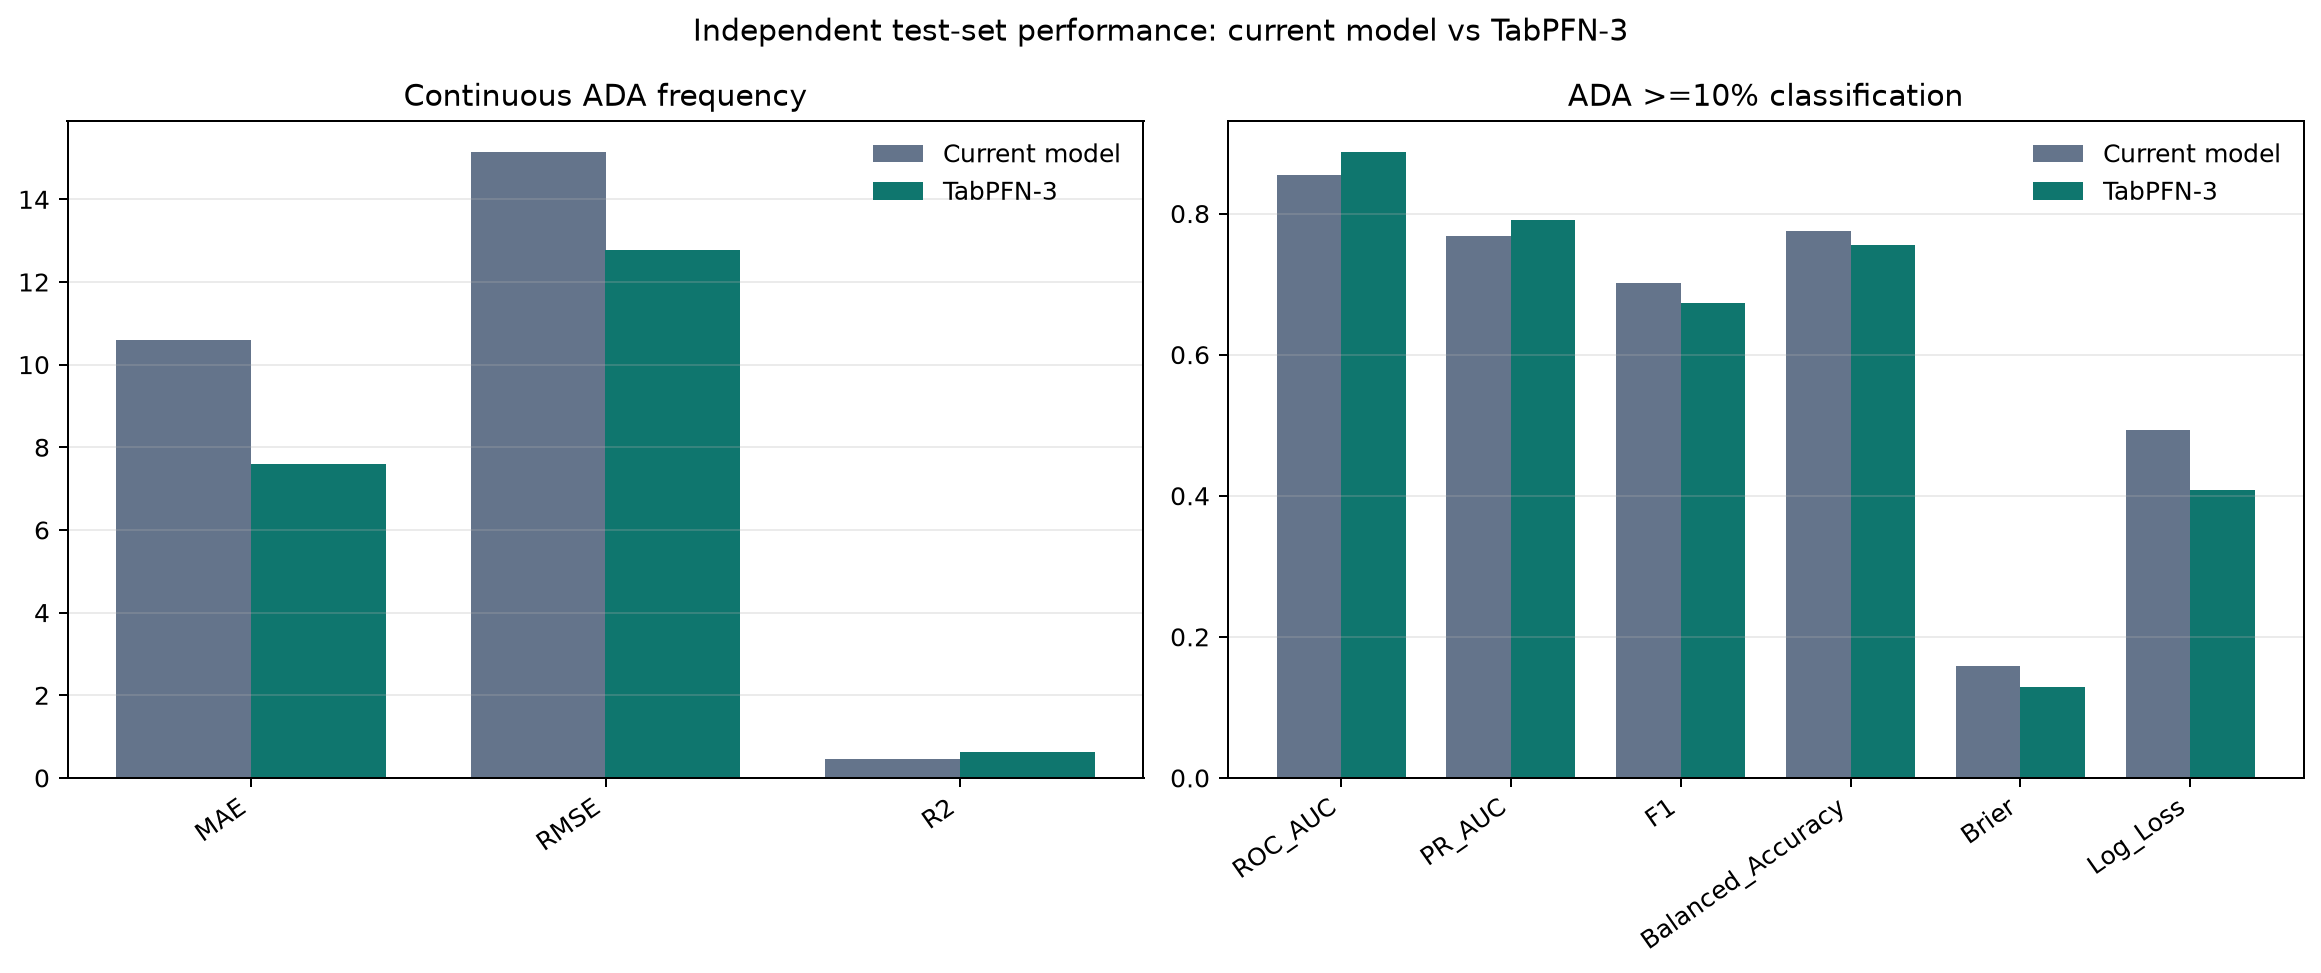

In [2]:
test = pd.read_csv(ART/'tabpfn_comparison.csv')
display(test)
display(Image(filename=str(ROOT/'outputs'/'modeling_figures'/'tabpfn_performance_comparison.png')))

## Development-set 5-fold grouped cross-validation

In [3]:
cv = pd.read_csv(ART/'tabpfn_cv_comparison.csv')
display(cv)

,outcome,metric,higher_is_better,current_model,current_cv_mean,current_cv_sd,tabpfn_model,tabpfn_cv_mean,tabpfn_cv_sd,tabpfn_improvement,winner_by_mean
0,continuous,MAE,False,Random forest,12.287496,1.103863,TabPFN-3,11.657880,0.997913,0.629616,TabPFN
1,continuous,RMSE,False,Random forest,19.377996,2.296161,TabPFN-3,19.395622,1.968908,-0.017626,Random forest
2,continuous,R2,True,Random forest,0.270152,0.131554,TabPFN-3,0.258005,0.182201,-0.012146,Random forest
3,binary,ROC_AUC,True,Random forest,0.804618,0.055017,TabPFN-3,0.793503,0.017239,-0.011114,Random forest
4,binary,PR_AUC,True,Random forest,0.694905,0.105158,TabPFN-3,0.675101,0.075352,-0.019804,Random forest
5,binary,F1,True,Random forest,0.596044,0.096772,TabPFN-3,0.579717,0.053872,-0.016327,Random forest
6,binary,Balanced_Accuracy,True,Random forest,0.700599,0.064026,TabPFN-3,0.696381,0.034194,-0.004218,Random forest
7,binary,Brier,False,Random forest,0.170328,0.021613,TabPFN-3,0.168007,0.015652,0.002321,TabPFN


## Paired cluster bootstrap on the sealed test set

In [4]:
boot = pd.read_csv(ART/'tabpfn_paired_bootstrap.csv')
display(boot)

,outcome,metric,higher_is_better,current_value,tabpfn_value,tabpfn_improvement,improvement_ci_2_5,improvement_ci_97_5,bootstrap_probability_tabpfn_better,bootstrap_repeats_valid,resampling_unit,conclusion
0,continuous,MAE,False,10.584620,7.600578,2.984042,1.449460,4.566627,1.0000,2000,model_split_group,TabPFN improvement supported
1,continuous,RMSE,False,15.142227,12.774754,2.367473,0.363188,4.522192,0.9925,2000,model_split_group,TabPFN improvement supported
2,continuous,R2,True,0.461286,0.616572,0.155286,0.021149,0.430880,0.9925,2000,model_split_group,TabPFN improvement supported
3,binary,ROC_AUC,True,0.855132,0.887134,0.032002,-0.006676,0.082143,0.9500,2000,model_split_group,Difference uncertain
4,binary,PR_AUC,True,0.767988,0.790282,0.022295,-0.032731,0.077613,0.7865,2000,model_split_group,Difference uncertain
5,binary,F1,True,0.701299,0.672811,-0.028488,-0.087800,0.019177,0.1345,2000,model_split_group,Difference uncertain
6,binary,Balanced_Accuracy,True,0.775483,0.754915,-0.020568,-0.056481,0.011230,0.1175,2000,model_split_group,Difference uncertain
7,binary,Brier,False,0.158656,0.128163,0.030493,0.009229,0.050436,0.9950,2000,model_split_group,TabPFN improvement supported
8,binary,Log_Loss,False,0.493628,0.407869,0.085759,0.030104,0.137911,0.9970,2000,model_split_group,TabPFN improvement supported


## TabPFN permutation importance

In [5]:
importance = pd.read_csv(ART/'tabpfn_feature_importance.csv')
for outcome in ['continuous','binary']:
    print(outcome)
    display(importance.query('outcome == @outcome').nlargest(10, 'importance_mean'))

continuous


,outcome,feature,importance_mean,importance_sd,repeats,importance_definition
0,continuous,antibody_backbone_clean,1.077974,0.194185,3,increase in MAE after permutation
1,continuous,target_group,1.054459,0.287450,3,increase in MAE after permutation
2,continuous,therapeutic_comparator,1.020557,0.224633,3,increase in MAE after permutation
3,continuous,log_n_ada_assessed,0.976454,0.175343,3,increase in MAE after permutation
4,continuous,moa_group,0.753587,0.155251,3,increase in MAE after permutation
5,continuous,log_assessment_days,0.725888,0.234450,3,increase in MAE after permutation
6,continuous,max_chain_length,0.671552,0.288867,3,increase in MAE after permutation
7,continuous,randomized_or_not,0.615913,0.233125,3,increase in MAE after permutation
8,continuous,ada_assay_platform,0.581128,0.027921,3,increase in MAE after permutation
9,continuous,trial_blinding,0.498081,0.197031,3,increase in MAE after permutation


binary


,outcome,feature,importance_mean,importance_sd,repeats,importance_definition
29,binary,log_total_sequence_length,0.056252,0.009438,3,decrease in ROC-AUC after permutation
30,binary,log_n_ada_assessed,0.051420,0.013439,3,decrease in ROC-AUC after permutation
31,binary,route_clean,0.040057,0.011021,3,decrease in ROC-AUC after permutation
32,binary,target_group,0.037212,0.006559,3,decrease in ROC-AUC after permutation
33,binary,max_chain_length,0.029432,0.009071,3,decrease in ROC-AUC after permutation
34,binary,therapeutic_comparator,0.020676,0.004788,3,decrease in ROC-AUC after permutation
35,binary,log_assessment_days,0.017156,0.000807,3,decrease in ROC-AUC after permutation
36,binary,trial_blinding,0.015234,0.005837,3,decrease in ROC-AUC after permutation
37,binary,randomized_or_not,0.015008,0.005567,3,decrease in ROC-AUC after permutation
38,binary,antibody_backbone_clean,0.012049,0.003778,3,decrease in ROC-AUC after permutation


## Prediction integrity checks

In [6]:
pred = pd.read_csv(ART/'tabpfn_predictions.csv')
checks = {
 'rows': len(pred),
 'unique_idc_row_id': pred.idc_row_id.is_unique,
 'finite_regression': np.isfinite(pred.tabpfn_regression_raw).all(),
 'finite_probability': np.isfinite(pred.tabpfn_probability_ada_high_10).all(),
 'regression_min': pred.tabpfn_regression_raw.min(),
 'regression_max': pred.tabpfn_regression_raw.max(),
 'probability_min': pred.tabpfn_probability_ada_high_10.min(),
 'probability_max': pred.tabpfn_probability_ada_high_10.max(),
}
display(pd.Series(checks, name='value').to_frame())
assert checks['rows'] == 374 and checks['unique_idc_row_id']
assert checks['finite_regression'] and checks['finite_probability']

,value
rows,374
unique_idc_row_id,True
finite_regression,True
finite_probability,True
regression_min,0.036751
regression_max,81.985733
probability_min,0.001194
probability_max,0.990727


## Interpretation

TabPFN-3 is the stronger test-set model for continuous prediction and probability ranking/calibration. Its cross-validation advantage is less consistent, and fixed-threshold F1/balanced accuracy do not improve. Retain both models until external or molecule-level validation confirms the replacement decision.